In [1]:
import os
import sys
import logging
import warnings
os.environ['FLAGS_log_level'] = '3'
logging.getLogger("ppocr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from paddleocr import PaddleOCR
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg
from basicsr.archs.rrdbnet_arch import RRDBNet
from torch.nn import functional as F
# from OCR.config import PATH_VGG_MODEL, device, LANG, PATH_IMAGE, PATH_REALESRGAN_MODEL

PATH_VGG_MODEL = 'experiments/vgg_transformer.pth'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
LANG = 'vi'
PATH_IMAGE = "data/synthetic_signboard.jpg"
PATH_REALESRGAN_MODEL = 'experiments/RealESRGAN_x4plus.pth'

def load_vietocr_model():
    config = Cfg.load_config_from_name('vgg_transformer')
    # config['weights'] = PATH_VGG_MODEL
    config['device'] = device
    return Predictor(config)

def load_realesrgan_model(scale=4):
    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=scale)
    loadnet = torch.load(PATH_REALESRGAN_MODEL, map_location=device)
    model.load_state_dict(loadnet['params_ema'], strict=True)
    model.eval()
    model = model.to(device)
    return model

def auto_rotate_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Cannot read image!!!")
        return None, None

    ocr = PaddleOCR(use_angle_cls=True, lang=LANG)
    result = ocr.ocr(image_path, cls=True)

    angles = []
    for line in result:
        for word in line:
            points = np.array(word[0], dtype=np.float32)
            x1, y1 = points[0]
            x2, y2 = points[1]
            angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
            angles.append(angle)

    if angles:
        avg_angle = np.mean(angles)
    else:
        return image, image

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    rot_mat = cv2.getRotationMatrix2D(center, avg_angle, 1.0)
    rotated = cv2.warpAffine(image, rot_mat, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return image, rotated

def enhance_image_with_realesrgan(image, model, scale=4):
    image = image.astype(np.float32) / 255.
    img_input = torch.from_numpy(np.transpose(image, (2, 0, 1))).unsqueeze(0).to(device)

    h, w = img_input.shape[2:]
    h_pad = (scale - h % scale) % scale
    w_pad = (scale - w % scale) % scale
    img_input = F.pad(img_input, (0, w_pad, 0, h_pad), 'reflect')

    with torch.no_grad():
        output = model(img_input)

    output_img = output.squeeze().float().cpu().clamp_(0, 1).numpy()
    output_img = np.transpose(output_img, (1, 2, 0))
    output_img = (output_img * 255.0).round().astype(np.uint8)

    return output_img

def detect_text_with_vietocr(image, vietocr_model):
    ocr = PaddleOCR(use_angle_cls=True, lang=LANG, det_db_box_thresh=0.3)
    result = ocr.ocr(image, cls=True)

    binary_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    recognized_texts = []

    for line in result:
        for word in line:
            points = np.array(word[0], dtype=np.int32)
            cv2.fillPoly(binary_mask, [points], 255)

            x_min, y_min = np.min(points, axis=0)
            x_max, y_max = np.max(points, axis=0)

            x_min = max(0, x_min - 10)
            y_min = max(0, y_min - 10)
            x_max = min(image.shape[1], x_max + 10)
            y_max = min(image.shape[0], y_max + 10)

            roi = image[y_min:y_max, x_min:x_max]
            if roi.shape[0] < 10 or roi.shape[1] < 10:
                recognized_texts.append("[ROI nhỏ/bị lỗi]")
                continue

            roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
            roi_pil = Image.fromarray(roi_rgb).resize((256, 32), Image.BILINEAR)

            try:
                text = vietocr_model.predict(roi_pil)
                recognized_texts.append(text)
            except:
                recognized_texts.append("[Lỗi OCR]")

    text_only = cv2.bitwise_and(image, image, mask=binary_mask)
    return text_only, recognized_texts

def visualize_result(text_image, original, ocr_texts):
    num_lines = len(ocr_texts)
    fig_height = max(5, num_lines * 0.4)
    fig = plt.figure(figsize=(12, fig_height))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.8])

    ax1 = plt.subplot(gs[0])
    ax1.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    ax1.set_title("Ảnh gốc (đã xoay)")
    ax1.axis("off")

    ax2 = plt.subplot(gs[1])
    ax2.imshow(cv2.cvtColor(text_image, cv2.COLOR_BGR2RGB))
    ax2.set_title("Ảnh vùng chữ (Real-ESRGAN)")
    ax2.axis("off")

    ax3 = plt.subplot(gs[2])
    ax3.axis("off")
    ax3.set_title("📝 Văn bản OCR", fontsize=12, loc='left')
    full_text = "\n".join([f"{i+1}. {txt}" for i, txt in enumerate(ocr_texts)])
    ax3.text(0, 1, full_text, fontsize=10, va='top', ha='left', wrap=True)

    plt.tight_layout()
    plt.show()
    

        


In [2]:
vietocr_model = load_vietocr_model()
realesrgan_model = load_realesrgan_model()


Model weight C:\Users\tuf\AppData\Local\Temp\vgg_transformer.pth exsits. Ignore download!


In [30]:
PATH_IMAGE = "data/bien_hieu2.png"
original, rotated = auto_rotate_image(PATH_IMAGE)

        

[2025/04/27 19:06:29] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\tuf/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\tuf/.paddleocr/whl\\rec\\latin\\latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320

[2025/04/27 19:06:31] ppocr DEBUG: dt_boxes num : 8, elapsed : 0.11651921272277832
[2025/04/27 19:06:31] ppocr DEBUG: cls num  : 8, elapsed : 0.055567264556884766
[2025/04/27 19:06:32] ppocr DEBUG: rec_res num  : 8, elapsed : 0.5406839847564697


In [31]:
enhanced_image = enhance_image_with_realesrgan(rotated, realesrgan_model)

In [32]:
text_image, ocr_texts = detect_text_with_vietocr(enhanced_image, vietocr_model)

[2025/04/27 19:10:58] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\tuf/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.3, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\tuf/.paddleocr/whl\\rec\\latin\\latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320

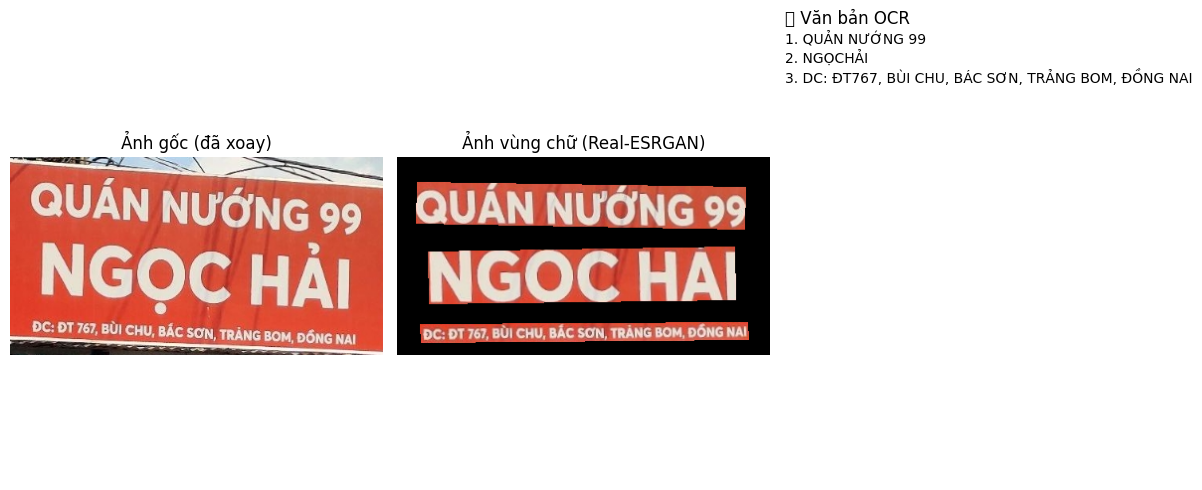

In [27]:
visualize_result(text_image, original, ocr_texts)

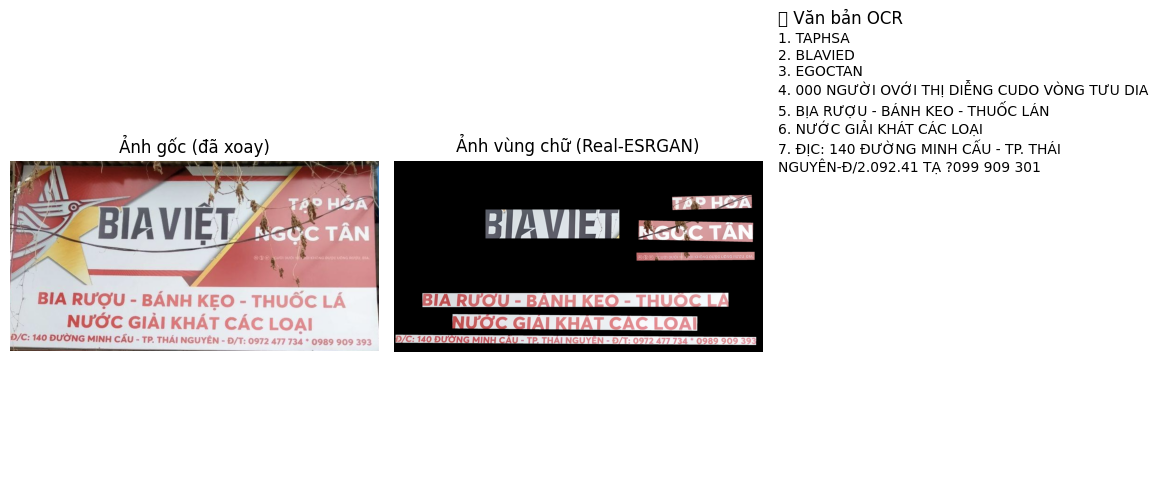

In [33]:
visualize_result(text_image, original, ocr_texts)


In [13]:
print(ocr_texts)


['QUẢN NƯỚNG 99', 'NGỌCHAI', 'DC. DT 767, BÙI CHU, BÁC SƠN, TRÀNG BOM, ĐỒNG NAI']


In [ ]:
import os

PATH_FOLDER = "data"
OUTPUT_FILE = "output_ocr.txt"

# Mở file output để ghi kết quả
with open(OUTPUT_FILE, "w", encoding="utf-8") as f_out:
    # Duyệt tất cả file trong thư mục
    for filename in os.listdir(PATH_FOLDER):
        image_path = os.path.join(PATH_FOLDER, filename)
        
        # Bỏ qua nếu không phải file ảnh
        if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            continue
        
        try:
            print(f"\nĐang xử lý ảnh: {filename}")
            
            original, rotated = auto_rotate_image(image_path)
            if rotated is not None:
                # Nếu bạn có enhance thì bật dòng dưới
                # enhanced_image = enhance_image_with_realesrgan(rotated, realesrgan_model)
                # text_image, ocr_texts = detect_text_with_vietocr(enhanced_image, vietocr_model)
                text_image, ocr_texts = detect_text_with_vietocr(rotated, vietocr_model)
                
                # Ghép các dòng text lại
                ocr_result = " ".join(ocr_texts)
                
                # In ra màn hình
                print(ocr_result)
                
                # Ghi vào file
                f_out.write(f"{ocr_result}\n")
                f_out.write("\n" + "-"*50 + "\n\n")
                
            else:
                print("Không xoay được ảnh.")
        
        except Exception as e:
            print(f"Lỗi khi xử lý ảnh {filename}: {e}")


In [5]:
print(" ".join(ocr_texts))

của hàng tựchón HUONGVY bavieth seavier 03000000002 215/12/1 PHƯỜNG PHÚ LOL TR THÚ DẦU MỘT, BD 0310856803227
